In [17]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [18]:
df = pd.read_parquet(path='df_limpo.parquet.gzip')

df_interlagos_2024 = pd.read_parquet(path='interlagos_2024.parquet')

df_silverstone_2024 = pd.read_parquet(path='silverstone_2024_n_tratado.parquet')

df = pd.concat([df, df_interlagos_2024, df_silverstone_2024], ignore_index=True)

In [19]:
display(df.tail(5))

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,Compound,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
49541,Fernando Alonso,0 days 00:01:31.430000,52.0,3.0,False,False,MEDIUM,14.0,True,1,8.0,Great Britain,2024,8.0,10.0,Finished,24.9,False
49542,Alexander Albon,0 days 00:01:29.718000,52.0,3.0,False,True,MEDIUM,14.0,True,1,9.0,Great Britain,2024,9.0,9.0,Finished,24.9,False
49543,Yuki Tsunoda,0 days 00:01:32.090000,52.0,3.0,False,False,SOFT,14.0,True,1,10.0,Great Britain,2024,10.0,13.0,Finished,24.9,False
49544,Logan Sargeant,0 days 00:01:32.088000,52.0,3.0,False,False,SOFT,14.0,True,1,11.0,Great Britain,2024,11.0,12.0,Finished,24.9,False
49545,Kevin Magnussen,0 days 00:01:31.982000,52.0,3.0,False,False,SOFT,15.0,True,1,12.0,Great Britain,2024,12.0,17.0,Finished,24.9,False


In [20]:
# Transformando a coluna LapTime em segundos, para melhor análise
df['LapTime'] = df['LapTime'].dt.total_seconds()

In [21]:
total_linhas = len(df)
total_nulos = len(df[df.isnull().any(axis=1)])
total_sem_info_pneus = len(df[df['Compound'] == 'UNKNOWN'])

total_removidas = total_nulos + total_sem_info_pneus

porcentagem_removidas = (total_removidas / total_linhas) * 100

print(total_linhas)
print(total_nulos)
print(total_sem_info_pneus)
print(f'Porcentagem de linhas removidas: {porcentagem_removidas:.2f}%')

49546
743
39
Porcentagem de linhas removidas: 1.58%


In [22]:
# Remove as linhas onde o tipo de pneu está como UNKNOWN
df = df[df['Compound'] != 'UNKNOWN']

In [23]:
# Setando um df separado apenas para os gráficos de barras, já que esses gráficos não vão utilizar a coluna LapTime
df_barras = df.copy(deep=True)

# Removendo voltas que não possuem tempo.
df = df[df['LapTime'].notna()]

In [24]:
df.tail()

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,Compound,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
49541,Fernando Alonso,91.430,52.0,3.0,False,False,MEDIUM,14.0,True,1,8.0,Great Britain,2024,8.0,10.0,Finished,24.9,False
49542,Alexander Albon,89.718,52.0,3.0,False,True,MEDIUM,14.0,True,1,9.0,Great Britain,2024,9.0,9.0,Finished,24.9,False
49543,Yuki Tsunoda,92.090,52.0,3.0,False,False,SOFT,14.0,True,1,10.0,Great Britain,2024,10.0,13.0,Finished,24.9,False
49544,Logan Sargeant,92.088,52.0,3.0,False,False,SOFT,14.0,True,1,11.0,Great Britain,2024,11.0,12.0,Finished,24.9,False
49545,Kevin Magnussen,91.982,52.0,3.0,False,False,SOFT,15.0,True,1,12.0,Great Britain,2024,12.0,17.0,Finished,24.9,False


In [25]:
display(df[df['Country'].isin(['United Kingdom'])].tail())

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,Compound,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall


In [26]:
for volta in range(1, 16):
    ag = {
        'FullName': 'Algoritmo Genético',
        'LapTime': 0,
        'LapNumber': volta,
        'Stint': 1,
        'PitStopBool': False,
        'IsPersonalBest': False,
        'Compound': 'SOFT',
        'TyreLife': volta,
        'FreshTyre': False,
        'TrackStatus': 1,
        'CurrentPosition': 0,
        'Country': 'Italy',
        'Year': 2023,
        'FinalPosition': 21,
        'GridPosition': 21,
        'Status': 'Finished',
        'TrackTemp': 29,
        'Rainfall': False
    }
    if volta == 15:
        ag = {
            'FullName': 'Algoritmo Genético',
            'LapTime': 0,
            'LapNumber': volta,
            'Stint': 1,
            'PitStopBool': True,
            'IsPersonalBest': False,
            'Compound': 'SOFT',
            'TyreLife': volta,
            'FreshTyre': False,
            'TrackStatus': 1,
            'CurrentPosition': 0,
            'Country': 'Italy',
            'Year': 2023,
            'FinalPosition': 21,
            'GridPosition': 21,
            'Status': 'Finished',
            'TrackTemp': 29,
            'Rainfall': False
    }
    df_barras.loc[len(df_barras)] = ag

In [27]:
for volta in range(16, 37):
    ag = {
        'FullName': 'Algoritmo Genético',
        'LapTime': 0,
        'LapNumber': volta,
        'Stint': 2,
        'PitStopBool': False,
        'IsPersonalBest': False,
        'Compound': 'SOFT',
        'TyreLife': volta,
        'FreshTyre': False,
        'TrackStatus': 1,
        'CurrentPosition': 0,
        'Country': 'Italy',
        'Year': 2023,
        'FinalPosition': 21,
        'GridPosition': 21,
        'Status': 'Finished',
        'TrackTemp': 29,
        'Rainfall': False
    }
    if volta == 36:
        ag = {
            'FullName': 'Algoritmo Genético',
            'LapTime': 0,
            'LapNumber': volta,
            'Stint': 2,
            'PitStopBool': True,
            'IsPersonalBest': False,
            'Compound': 'SOFT',
            'TyreLife': volta,
            'FreshTyre': False,
            'TrackStatus': 1,
            'CurrentPosition': 0,
            'Country': 'Italy',
            'Year': 2023,
            'FinalPosition': 21,
            'GridPosition': 21,
            'Status': 'Finished',
            'TrackTemp': 29,
            'Rainfall': False
    }
    df_barras.loc[len(df_barras)] = ag

In [28]:
for volta in range(36, 50):
    ag = {
        'FullName': 'Algoritmo Genético',
        'LapTime': 0,
        'LapNumber': volta,
        'Stint': 3,
        'PitStopBool': False,
        'IsPersonalBest': False,
        'Compound': 'MEDIUM',
        'TyreLife': volta,
        'FreshTyre': False,
        'TrackStatus': 1,
        'CurrentPosition': 0,
        'Country': 'Italy',
        'Year': 2023,
        'FinalPosition': 21,
        'GridPosition': 0,
        'Status': 'Finished',
        'TrackTemp': 29,
        'Rainfall': False
    }
    df_barras.loc[len(df_barras)] = ag

In [29]:
df_barras.tail()

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,Compound,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
49541,Fernando Alonso,91.430,52.0,3.0,False,False,MEDIUM,14.0,True,1,8.0,Great Britain,2024,8.0,10.0,Finished,24.9,False
49542,Alexander Albon,89.718,52.0,3.0,False,True,MEDIUM,14.0,True,1,9.0,Great Britain,2024,9.0,9.0,Finished,24.9,False
49543,Yuki Tsunoda,92.090,52.0,3.0,False,False,SOFT,14.0,True,1,10.0,Great Britain,2024,10.0,13.0,Finished,24.9,False
49544,Logan Sargeant,92.088,52.0,3.0,False,False,SOFT,14.0,True,1,11.0,Great Britain,2024,11.0,12.0,Finished,24.9,False
49545,Kevin Magnussen,91.982,52.0,3.0,False,False,SOFT,15.0,True,1,12.0,Great Britain,2024,12.0,17.0,Finished,24.9,False


### Selecionamos apenas as voltas com TrackStatus = 1
#### TrackStatus: 
‘1’: Track clear (beginning of session or to indicate the end
of another status)

‘2’: Yellow flag (sectors are unknown)

‘3’: ??? Never seen so far, does not exist?

‘4’: Safety Car

‘5’: Red Flag

‘6’: Virtual Safety Car deployed

‘7’: Virtual Safety Car ending (As indicated on the drivers steering wheel, on tv and so on; status ‘1’ will mark the actual end)

In [30]:
df = df.loc[df['TrackStatus'] == '1']

In [31]:
df_anos_pneus_pirelli = df.loc[df['Year'].isin([2022, 2023, 2024])]

### Criar a coluna PitStops utilizando a fórmula -> PitStops = Stint - 1

In [32]:
df['PitStops'] = df['Stint'] - 1

pitstops = df.pop('PitStops')

df.insert(6, 'PitStops', pitstops)

In [33]:

df_anos_pneus_pirelli['PitStops'] = df_anos_pneus_pirelli['Stint'] - 1

pitstops = df_anos_pneus_pirelli.pop('PitStops')

df_anos_pneus_pirelli.insert(6, 'PitStops', pitstops)

/tmp/ipykernel_23948/2389531145.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anos_pneus_pirelli['PitStops'] = df_anos_pneus_pirelli['Stint'] - 1


In [34]:
df_anos_pneus_pirelli.tail()

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,PitStops,Compound,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
49541,Fernando Alonso,91.430,52.0,3.0,False,False,2.0,MEDIUM,14.0,True,1,8.0,Great Britain,2024,8.0,10.0,Finished,24.9,False
49542,Alexander Albon,89.718,52.0,3.0,False,True,2.0,MEDIUM,14.0,True,1,9.0,Great Britain,2024,9.0,9.0,Finished,24.9,False
49543,Yuki Tsunoda,92.090,52.0,3.0,False,False,2.0,SOFT,14.0,True,1,10.0,Great Britain,2024,10.0,13.0,Finished,24.9,False
49544,Logan Sargeant,92.088,52.0,3.0,False,False,2.0,SOFT,14.0,True,1,11.0,Great Britain,2024,11.0,12.0,Finished,24.9,False
49545,Kevin Magnussen,91.982,52.0,3.0,False,False,2.0,SOFT,15.0,True,1,12.0,Great Britain,2024,12.0,17.0,Finished,24.9,False


In [35]:
df_anos_pneus_pirelli.to_parquet('data_pneus.parquet')

### Selecionar a melhor volta de todos corredores em uma mesma pista:

In [36]:
def get_drivers_bast_lap(df, year, country):
    df = df.loc[(df['Year'] == year) & (df['Country'] == country)]
    fastest_laps = df.loc[df.groupby('FullName')['LapTime'].idxmin()]
    fastest_laps = fastest_laps[['FullName', 'LapTime', 'LapNumber', 'Stint', 'PitStops', 'Compound', 'TyreLife', 'FreshTyre', 'TrackTemp', 'Rainfall']]
    fastest_laps = fastest_laps.sort_values(by=['LapTime'], ascending=True)
    print(f'Printando o DataFrame com as melhores voltas de todos os pilotos no circuito {country}, ano {year}:')
    display(fastest_laps)
    modas = fastest_laps.mode(numeric_only=True).iloc[0]
    print(f'Printando o DataFrame com a moda dos atributos no circuito {country}, ano {year}:')
    display(modas)


get_drivers_bast_lap(df, 2024, 'Great Britain')


Printando o DataFrame com as melhores voltas de todos os pilotos no circuito Great Britain, ano 2024:


,FullName,LapTime,LapNumber,Stint,PitStops,Compound,TyreLife,FreshTyre,TrackTemp,Rainfall
49537,Carlos Sainz,88.293,52.0,4.0,3.0,SOFT,5.0,False,24.9,False
49515,Oscar Piastri,88.748,51.0,3.0,2.0,MEDIUM,13.0,True,25.3,False
49461,Max Verstappen,88.952,48.0,3.0,2.0,HARD,10.0,True,25.2,False
49370,Lando Norris,89.262,43.0,3.0,2.0,SOFT,6.0,False,25.0,False
49405,Lewis Hamilton,89.438,45.0,3.0,2.0,SOFT,8.0,False,24.5,True
49534,Sergio Perez,89.707,50.0,5.0,4.0,SOFT,3.0,True,25.2,False
49451,Fernando Alonso,89.710,47.0,3.0,2.0,MEDIUM,9.0,True,24.9,False
49542,Alexander Albon,89.718,52.0,3.0,2.0,MEDIUM,14.0,True,24.9,False
49393,Charles Leclerc,89.748,43.0,4.0,3.0,SOFT,6.0,True,24.5,True
49377,Nico Hulkenberg,89.836,43.0,3.0,2.0,SOFT,7.0,False,24.9,False


Printando o DataFrame com a moda dos atributos no circuito Great Britain, ano 2024:


LapTime      88.293
LapNumber      43.0
Stint           3.0
PitStops        2.0
TyreLife        7.0
FreshTyre      True
TrackTemp      24.9
Rainfall      False
Name: 0, dtype: object

### Função para remover os OUTLIERS

In [37]:
def remove_outliers_by_laptime(df):
    Q1 = df.groupby('Composto')['LapTime'].quantile(.25)
    Q3 = df.groupby('Composto')['LapTime'].quantile(0.75)
    IQR = Q3 - Q1
    LIMITE_SUPERIOR = Q3 + (1.5 * IQR)

    # Criar uma nova coluna IsLapTimeOutlier, marcando as linhas com valores acima do limite superior como True
    df['IsLapTimeOutlier'] = df.apply(lambda row: row['LapTime'] > LIMITE_SUPERIOR[row['Composto']], axis=1)

    # Remover os outliers (onde IsLapTimeOutlier é True)
    df_cleaned = df[df['IsLapTimeOutlier'] == False].copy()
    
    # Remover a coluna IsLapTimeOutlier para limpar o DataFrame
    df_cleaned.drop(columns=['IsLapTimeOutlier'], inplace=True)
    
    return df_cleaned

### Seleciona o total de voltas em cada Stint

In [38]:
def get_total_laps_by_stint(df, year, country):
    df = df.loc[(df['Year'] == year) & (df['Country'] == country)].sort_values(by=['FullName', 'LapNumber'])
    # Calcular o número de voltas por Stint
    stint_laps = df.groupby(['FullName', 'Stint']).size().reset_index(name='NumLaps')

    # Exibir o resultado
    display(stint_laps)

get_total_laps_by_stint(df, 2024, 'Great Britain')

,FullName,Stint,NumLaps
0,Alexander Albon,1.0,27
1,Alexander Albon,2.0,11
2,Alexander Albon,3.0,14
3,Carlos Sainz,1.0,26
4,Carlos Sainz,2.0,13
5,Carlos Sainz,3.0,11
6,Carlos Sainz,4.0,2
7,Charles Leclerc,1.0,19
8,Charles Leclerc,2.0,8
9,Charles Leclerc,3.0,10


### Seleciona o tempo total das voltas durante determinado Stint

In [39]:
def get_total_time_by_stint(df, year, country):
    df = df.loc[(df['Year'] == year) & (df['Country'] == country)].sort_values(by=['FullName', 'LapNumber'])
    # Agrupar por Driver e Stint e somar os tempos de volta em cada Stint
    stint_times = df.groupby(['FullName', 'Stint', 'Compound'])['LapTime'].sum().reset_index()
    stint_times = stint_times.rename(columns={'LapTime': 'TotalStintTime'})
    # Exibir o resultado
    display(stint_times)

get_total_time_by_stint(df, 2024, 'Great Britain')

,FullName,Stint,Compound,TotalStintTime
0,Alexander Albon,1.0,MEDIUM,2567.144
1,Alexander Albon,2.0,INTERMEDIATE,1157.418
2,Alexander Albon,3.0,MEDIUM,1290.884
3,Carlos Sainz,1.0,MEDIUM,2436.078
4,Carlos Sainz,2.0,INTERMEDIATE,1343.731
5,Carlos Sainz,3.0,HARD,1013.729
6,Carlos Sainz,4.0,SOFT,200.839
7,Charles Leclerc,1.0,MEDIUM,1785.140
8,Charles Leclerc,2.0,INTERMEDIATE,866.660
9,Charles Leclerc,3.0,INTERMEDIATE,1042.468


### Análise "tempo de volta x desgaste"

In [40]:
mapa = {
    'SOFT': 'MACIO',
    'MEDIUM': 'MÉDIO',
    'HARD': 'DURO',
    'INTERMEDIATE': 'INTERMEDIÁRIO',
    'WET': 'CHUVA'
}

df = df.rename(columns={'Compound': 'Composto'})
df['Composto'] = df['Composto'].map(mapa)

In [41]:
df.head()

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,PitStops,Composto,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
2,Pierre Gasly,98.794,3.0,1.0,False,True,0.0,MACIO,6.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.3,False
4,Pierre Gasly,98.574,5.0,1.0,False,True,0.0,MACIO,8.0,False,1,11.0,Bahrain,2019,8.0,13.0,Finished,29.2,False
6,Pierre Gasly,100.112,7.0,1.0,False,False,0.0,MACIO,10.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.1,False
7,Pierre Gasly,99.189,8.0,1.0,False,False,0.0,MACIO,11.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.1,False
8,Pierre Gasly,102.197,9.0,1.0,True,False,0.0,MACIO,12.0,False,1,13.0,Bahrain,2019,8.0,13.0,Finished,28.9,False


In [42]:
paises = {
    'Bahrain': 'Bahrain',
    'Spain': 'Espanha',
    'Italy': 'Itália',
    'Austria': 'Áustria',
    'Great Britain': 'Grã-Betanha',
    'Hungary': 'Hungria',
    'Belgium': 'Bélgica',
    'United Arab Emirates': 'Emirados Árabes Unidos',
    'Abu Dhabi': 'Abu Dhabi',
    'Brazil': 'Brasil',
    'Great Britain': 'Reino Unido'
}

df['Country'] = df['Country'].map(paises)


In [43]:
df_barras['Country'] = df_barras['Country'].map(paises)

In [44]:
display(df.head())

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,PitStops,Composto,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
2,Pierre Gasly,98.794,3.0,1.0,False,True,0.0,MACIO,6.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.3,False
4,Pierre Gasly,98.574,5.0,1.0,False,True,0.0,MACIO,8.0,False,1,11.0,Bahrain,2019,8.0,13.0,Finished,29.2,False
6,Pierre Gasly,100.112,7.0,1.0,False,False,0.0,MACIO,10.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.1,False
7,Pierre Gasly,99.189,8.0,1.0,False,False,0.0,MACIO,11.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.1,False
8,Pierre Gasly,102.197,9.0,1.0,True,False,0.0,MACIO,12.0,False,1,13.0,Bahrain,2019,8.0,13.0,Finished,28.9,False


In [45]:
df['Country'].unique()

array(['Bahrain', 'Espanha', 'Áustria', 'Reino Unido', 'Hungria',
       'Bélgica', 'Itália', 'Emirados Árabes Unidos', 'Abu Dhabi',
       'Brasil'], dtype=object)

/tmp/ipykernel_23948/107095467.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IsLapTimeOutlier'] = df.apply(lambda row: row['LapTime'] > LIMITE_SUPERIOR[row['Composto']], axis=1)


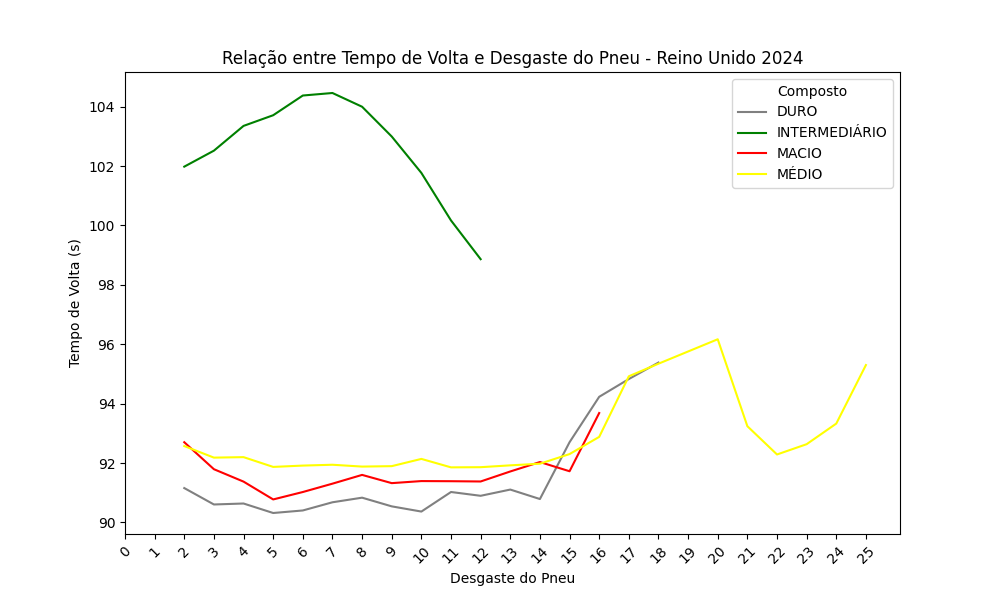

O ponto ideal do Composto DURO, o pneu tinha dado 5 voltas e o tempo médio foi de 90.31833333333334 segundos.
O ponto ideal do Composto INTERMEDIÁRIO, o pneu tinha dado 12 voltas e o tempo médio foi de 98.86566666666666 segundos.
O ponto ideal do Composto MACIO, o pneu tinha dado 5 voltas e o tempo médio foi de 90.77492307692309 segundos.
O ponto ideal do Composto MÉDIO, o pneu tinha dado 11 voltas e o tempo médio foi de 91.85514285714287 segundos.


In [46]:
def laptime_and_tyrelife_analysis_all_drivers_mean(df, year, country):
    # Aqui buscamos apenas voltas que não sejam a primeira volta da corrida e voltas que não sejam a primeira volta de determinado tipo de pneu, pois a primeira volta do pneu é bem mais lenta, pois inclui o tempo do pitsop (troca de pneu)
    df = df.loc[(df['Year'] == year) & (df['Country'] == country) & (df['LapNumber'] != 1) & (df['TyreLife'] != 1) & (df['PitStopBool'] == False)]
    
    # Limpando os outliers com a função que criamos anteriormente
    df = remove_outliers_by_laptime(df)
    # Agrupando a média da coluna LapTime por composto e vida do pneu
    tyre_life_analysis = df.groupby(['Composto', 'TyreLife'])['LapTime'].mean().reset_index()

    # Plotando o gráfico
    plt.figure(figsize=(10, 6), facecolor='#FFFFFF')
    sns.lineplot(data=tyre_life_analysis, x='TyreLife', y='LapTime', hue='Composto', palette=['Grey', 'Green', 'Red', 'Yellow'])
    plt.title('Relação entre Tempo de Volta e Desgaste do Pneu - ' + country + ' ' + str(year), color='#000000')
    plt.xlabel('Desgaste do Pneu', color='#000000')
    plt.ylabel('Tempo de Volta (s)', color='#000000')
    x_ticks = np.arange(0, tyre_life_analysis['TyreLife'].max() + 1, 1)  # Define ticks de 1 em 1
    plt.xticks(x_ticks, rotation=45)
    ax = plt.gca()  # Acessa o eixo atual
    ax.tick_params(axis='x', colors='#000000')  # Cor dos números do eixo X
    ax.tick_params(axis='y', colors='#000000')   # Cor dos números do eixo Y
    ax.set_facecolor('#FFFFFF')  # Define a cor de fundo (usando uma cor hexadecimal)
    plt.show()

    # Selecionando a volta
    optimal_point = tyre_life_analysis.loc[tyre_life_analysis.groupby('Composto')['LapTime'].idxmin()]
    for index, row in optimal_point.iterrows():
        print(f'O ponto ideal do Composto {row["Composto"]}, o pneu tinha dado {str(int(row["TyreLife"]))} voltas e o tempo médio foi de {row["LapTime"]} segundos.')
laptime_and_tyrelife_analysis_all_drivers_mean(df, 2024, 'Reino Unido')

/tmp/ipykernel_23948/107095467.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IsLapTimeOutlier'] = df.apply(lambda row: row['LapTime'] > LIMITE_SUPERIOR[row['Composto']], axis=1)
/tmp/ipykernel_23948/2083998040.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='TyreLife', y='LapTime', hue='Composto', palette=['Red', 'Yellow', 'Grey'], ci=None)


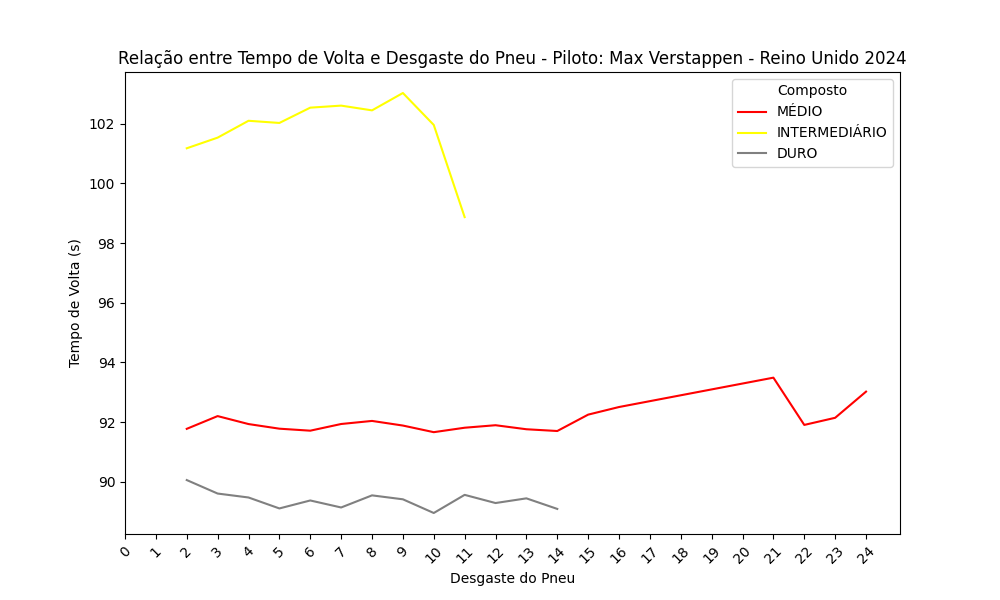

O ponto ideal do composto DURO, o pneu tinha dado 10 voltas e o tempo médio foi de 88.952 segundos.
O ponto ideal do composto INTERMEDIÁRIO, o pneu tinha dado 11 voltas e o tempo médio foi de 98.869 segundos.
O ponto ideal do composto MÉDIO, o pneu tinha dado 10 voltas e o tempo médio foi de 91.661 segundos.


In [47]:
def laptime_and_tyrelife_analysis_driver(df, year, country, driver):
    # Aqui buscamos apenas voltas que não sejam a primeira volta da corrida e voltas que não sejam a primeira volta de determinado tipo de pneu, pois a primeira volta do pneu é bem mais lenta, pois inclui o tempo do pitsop (troca de pneu)
    df = df.loc[(df['Year'] == year) & (df['Country'] == country) & (df['LapNumber'] != 1) & (df['TyreLife'] != 1) & (df['FullName'] == driver) & (df['PitStopBool'] == False)]

    # Limpando os outliers com a função que criamos anteriormente
    df = remove_outliers_by_laptime(df)

    # Plotando o gráfico
    plt.figure(figsize=(10, 6), facecolor='#FFFFFF')
    sns.lineplot(data=df, x='TyreLife', y='LapTime', hue='Composto', palette=['Red', 'Yellow', 'Grey'], ci=None)
    plt.title('Relação entre Tempo de Volta e Desgaste do Pneu - Piloto: ' + driver + ' - ' + str(country) + ' ' + str(year), color='#000000')
    plt.xlabel('Desgaste do Pneu', color='#000000')
    plt.ylabel('Tempo de Volta (s)', color='#000000')
    x_ticks = np.arange(0, df['TyreLife'].max() + 1, 1)  # Define ticks de 1 em 1
    plt.xticks(x_ticks, rotation=45)
    ax = plt.gca()  # Acessa o eixo atual
    ax.tick_params(axis='x', colors='#000000')  # Cor dos números do eixo X
    ax.tick_params(axis='y', colors='#000000')   # Cor dos números do eixo Y
    ax.set_facecolor('#FFFFFF')  # Define a cor de fundo (usando uma cor hexadecimal)
    plt.show()

    # Selecionando a volta
    optimal_point = df.loc[df.groupby('Composto')['LapTime'].idxmin()]
    for index, row in optimal_point.iterrows():
        print(f'O ponto ideal do composto {row["Composto"]}, o pneu tinha dado {str(int(row["TyreLife"]))} voltas e o tempo médio foi de {row["LapTime"]} segundos.')
laptime_and_tyrelife_analysis_driver(df, 2024, 'Reino Unido', 'Max Verstappen')

### Gráfico contínuo de LapTime x LapNumber do piloto vencedor de determinada corrida

In [48]:
def plot_laptime_with_tyre_changes(df, year, country):
    # Dicionário com as cores dos pneus
    compound_colors = {
        'MACIO': '#da291c',
        'MÉDIO': '#ffd12e',
        'DURO': '#f0f0ec',
        'INTERMEDIÁRIO': '#43b02a',
        'CHUVA': '#0067ad'
    }

    # Filtrar o DataFrame para o ano e país fornecido
    race_data = df[(df['Year'] == year) & (df['Country'] == country)]

    # Pegar o vencedor da corrida (assumindo que 'FinalPosition' == 1 é o vencedor)
    winner_data = race_data[race_data['FinalPosition'] == 1]

    # Ordenar os dados por número de volta (LapNumber)
    winner_data = winner_data.sort_values(by='LapNumber')

    # Preparar a figura e o eixo
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#FFFFFF')

    # Inicializar a variável para armazenar o ponto de início da linha
    previous_lap = winner_data.iloc[0]['LapNumber']
    previous_lap_time = winner_data.iloc[0]['LapTime']
    previous_compound = winner_data.iloc[0]['Composto']

    # Loop sobre as voltas do vencedor e plotar com a cor de cada pneu
    for idx, row in winner_data.iterrows():
        lap_number = row['LapNumber']
        lap_time = row['LapTime']
        compound = row['Composto']

        # Se o composto mudou, desenhar um segmento da linha
        if compound != previous_compound:
            # Plotar a linha com o composto anterior
            ax.plot(
                [previous_lap, lap_number],
                [previous_lap_time, lap_time],
                color=compound_colors[previous_compound],
                linewidth=2,
                label='oi'
            )

            # Atualizar o composto anterior
            previous_compound = compound
        else:
            # Plotar a linha se o composto for o mesmo
            ax.plot(
                [previous_lap, lap_number],
                [previous_lap_time, lap_time],
                color=compound_colors[compound],
                linewidth=2
            )

        # Atualizar o ponto anterior para a próxima iteração
        previous_lap = lap_number
        previous_lap_time = lap_time
    
    # Detalhar o eixo X com mais marcações
    max_lap = int(winner_data['LapNumber'].max())
    ax.set_xticks(range(0, max_lap + 1, 5))  # Define marcações a cada volta
    # Adicionar rótulos e título ao gráfico
    plt.title(f'Voltas do piloto: {winner_data.iloc[0]['FullName']} - {country} {year}', color='#000000')
    plt.xlabel('Número da volta', color='#000000')
    plt.ylabel('Tempo de volta (s)', color='#000000')
    # Personalizar o gráfico (cor dos eixos e fundo)
    ax.tick_params(axis='x', colors='#000000')
    ax.tick_params(axis='y', colors='#000000')
    ax.set_facecolor('#FFFFFF')
    # Definir os intervalos do eixo Y e formatar os rótulos
    min_time = winner_data['LapTime'].min()
    max_time = winner_data['LapTime'].max()
    tyre_legend = [
        mpatches.Patch(color=compound_colors['MACIO'], label='MACIO'),
        mpatches.Patch(color=compound_colors['MÉDIO'], label='MÉDIO')
        #mpatches.Patch(color=compound_colors['INTERMEDIATE'], label='INTERMEDIATE'),
        #mpatches.Patch(color=compound_colors['WET'], label='WET')
    ]

    tyre_legend_artist = ax.legend(handles=tyre_legend, title="Composto", loc='upper right')

    ax.set_yticks(range(int(min_time), int(max_time) + 1, 1))  # Ajustar o intervalo conforme necessário

    # Remover as bordas superiores e direitas do gráfico
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Exibir o gráfico
    plt.show()

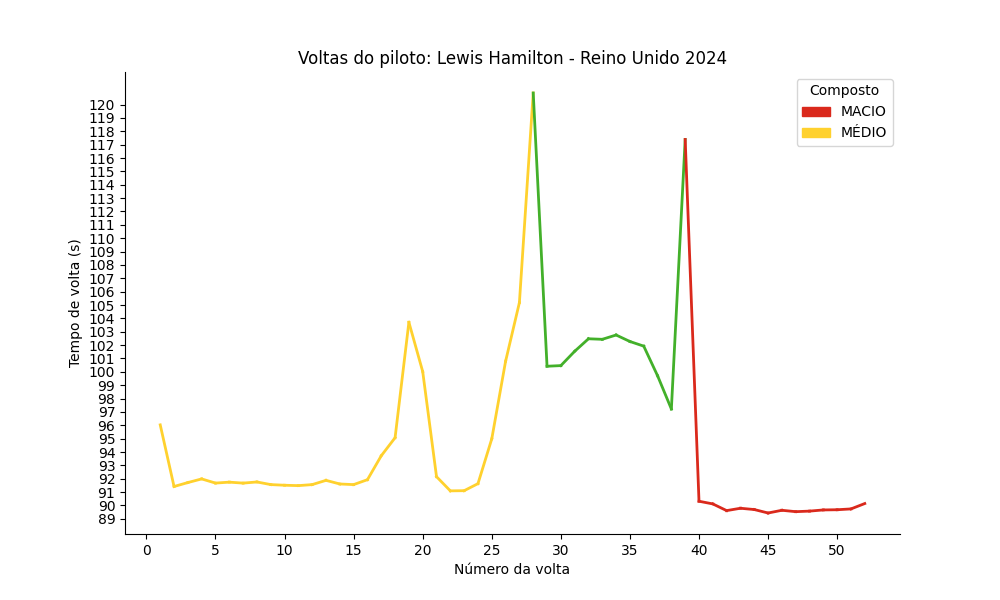

In [49]:
plot_laptime_with_tyre_changes(df, 2024, 'Reino Unido')

### Gráfico de barras segmentado dos pilotos baseado no Stint

In [50]:
def get_tyre_strategy_by_year_and_country(df, year, country):
    # Dicionario com as cores possiveis dos pneus
    compound_colors = {
        'SOFT': '#da291c',
        'MEDIUM': '#ffd12e',
        'HARD': '#f0f0ec',
        'INTERMEDIATE': '#43b02a',
        'WET': '#0067ad'
    }

    df = df.loc[(df['Year'] == year) & (df['Country'] == country)]
    drivers = df.loc[(df['Year'] == year) & (df['Country'] == country)].sort_values('FinalPosition')['FullName'].unique()
    stints = df[["FullName", "Stint", "Compound", "LapNumber"]]
    stints = stints.groupby(["FullName", "Stint", "Compound"])
    stints = stints.count().reset_index()
    stints = stints.rename(columns={"LapNumber": "StintLength"})
    fig, ax = plt.subplots(figsize=(12, 16), facecolor='#FFFFFF')

    # Pegando o piloto campeão
    winner = df[df['FinalPosition'] == 1]['FullName'].iloc[0]
    second = df[df['FinalPosition'] == 2]['FullName'].iloc[0]
    third = df[df['FinalPosition'] == 3]['FullName'].iloc[0]

    # Pegando o piloto que mais ganhou posições
    position_changes = df.groupby('FullName').apply(lambda g: g['GridPosition'].iloc[0] - g['FinalPosition'].iloc[-1], include_groups=False)
    most_improved_driver = position_changes.idxmax()
    total_laps = int(df['LapNumber'].max())

    for driver in drivers:
        driver_stints = stints.loc[stints["FullName"] == driver]
        previous_stint_end = 0
        total_positions_gained = position_changes[driver]
        for idx, row in driver_stints.iterrows():
            if driver == winner:
                edge_color = '#d4af37'
            elif driver == second:
                edge_color = '#c0c0c0'
            elif driver == third:
                edge_color = '#cd7f32'
            elif driver == most_improved_driver:
                edge_color = 'purple'
            else:
                edge_color = 'black'
            # Rachura para o piloto que mais ganhou posições
            hatch = '//' if driver == most_improved_driver else None
            # each row contains the compound name and stint length
            # we can use these information to draw horizontal bars
            bars = plt.barh(
                y=driver,
                width=row["StintLength"],
                left=previous_stint_end,
                color=compound_colors[row['Compound']],
                edgecolor=edge_color,
                hatch=hatch,
                label=row['Compound'],
                fill=True
            )

            # Adicionar o texto com o número de voltas por stint dentro da barra
            ax.text(
                previous_stint_end + row["StintLength"] / 2,  # Posição centralizada dentro da barra
                driver,
                f'{row["StintLength"]} voltas',
                va='center',  # Alinhamento vertical do texto
                ha='center',  # Alinhamento horizontal do texto
                color='black',
                fontsize=10
            )

            previous_stint_end += row["StintLength"]
    
        # Adicionar o texto com o total de posições ganhas ao lado da barra
        ax.text(
            previous_stint_end + 2,  # Ajuste para o posicionamento do texto
            driver,
            f'{int(total_positions_gained)} pos.',
            va='center',  # Alinhamento vertical do texto
            color='black',
            fontsize=10
        )
    
    # Ajustar a cor do texto dos labels no eixo Y
    for label in ax.get_yticklabels():
        if label.get_text() == winner:
            label.set_color('#d4af37') 
        elif label.get_text() == second:
            label.set_color('#c0c0c0')
        elif label.get_text() == third:
            label.set_color('#cd7f32')
        elif label.get_text() == most_improved_driver:
            label.set_color('purple')
        else:
           label.set_color('#000000')

    plt.title(f'Grande Prêmio do {country} - {year} - (Total de Voltas: {total_laps}) - Estratégia de Pneus',  color='#000000')
    plt.xlabel("Número da volta",  color='#000000')
    ax.tick_params(axis='x', colors='#000000')  # Cor dos números do eixo X
    ax.set_facecolor('#FFFFFF')  # Define a cor de fundo
    plt.grid(False)
   
    ax.set_xticks(range(0, total_laps + 1, 5))
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    tyre_legend = [
        mpatches.Patch(color=compound_colors['SOFT'], label='MACIO'),
        mpatches.Patch(color=compound_colors['MEDIUM'], label='MÉDIO'),
        mpatches.Patch(color=compound_colors['HARD'], label='DURO')
        #mpatches.Patch(color=compound_colors['INTERMEDIATE'], label='INTERMEDIATE'),
        #mpatches.Patch(color=compound_colors['WET'], label='WET')
    ]

    tyre_legend_artist = ax.legend(handles=tyre_legend, title="Legenda dos Pneus", loc='upper left', bbox_to_anchor=(-0.15, 1.1))
    ax.add_artist(tyre_legend_artist)  # Adiciona a legenda dos pneus separadamente
    pilot_legend = [
        mpatches.Patch(color='#d4af37', label='Vencedor'),
        mpatches.Patch(color='#c0c0c0', label='Segundo Lugar'),
        mpatches.Patch(color='#cd7f32', label='Terceiro Lugar'),
        mpatches.Patch(color='purple', label='Ganhou mais posições')
    ]
    plt.legend(handles=pilot_legend, title="Legenda dos Pilotos", loc='upper left', bbox_to_anchor=(0.03, 1.1))


    plt.tight_layout()
    plt.show()

### Printando o gráfico para cada corrida em todos os anos
Esse gráfico apresenta informações sobre a estratégia de pneus e pitstops de todos os pilotos em determinada corrida

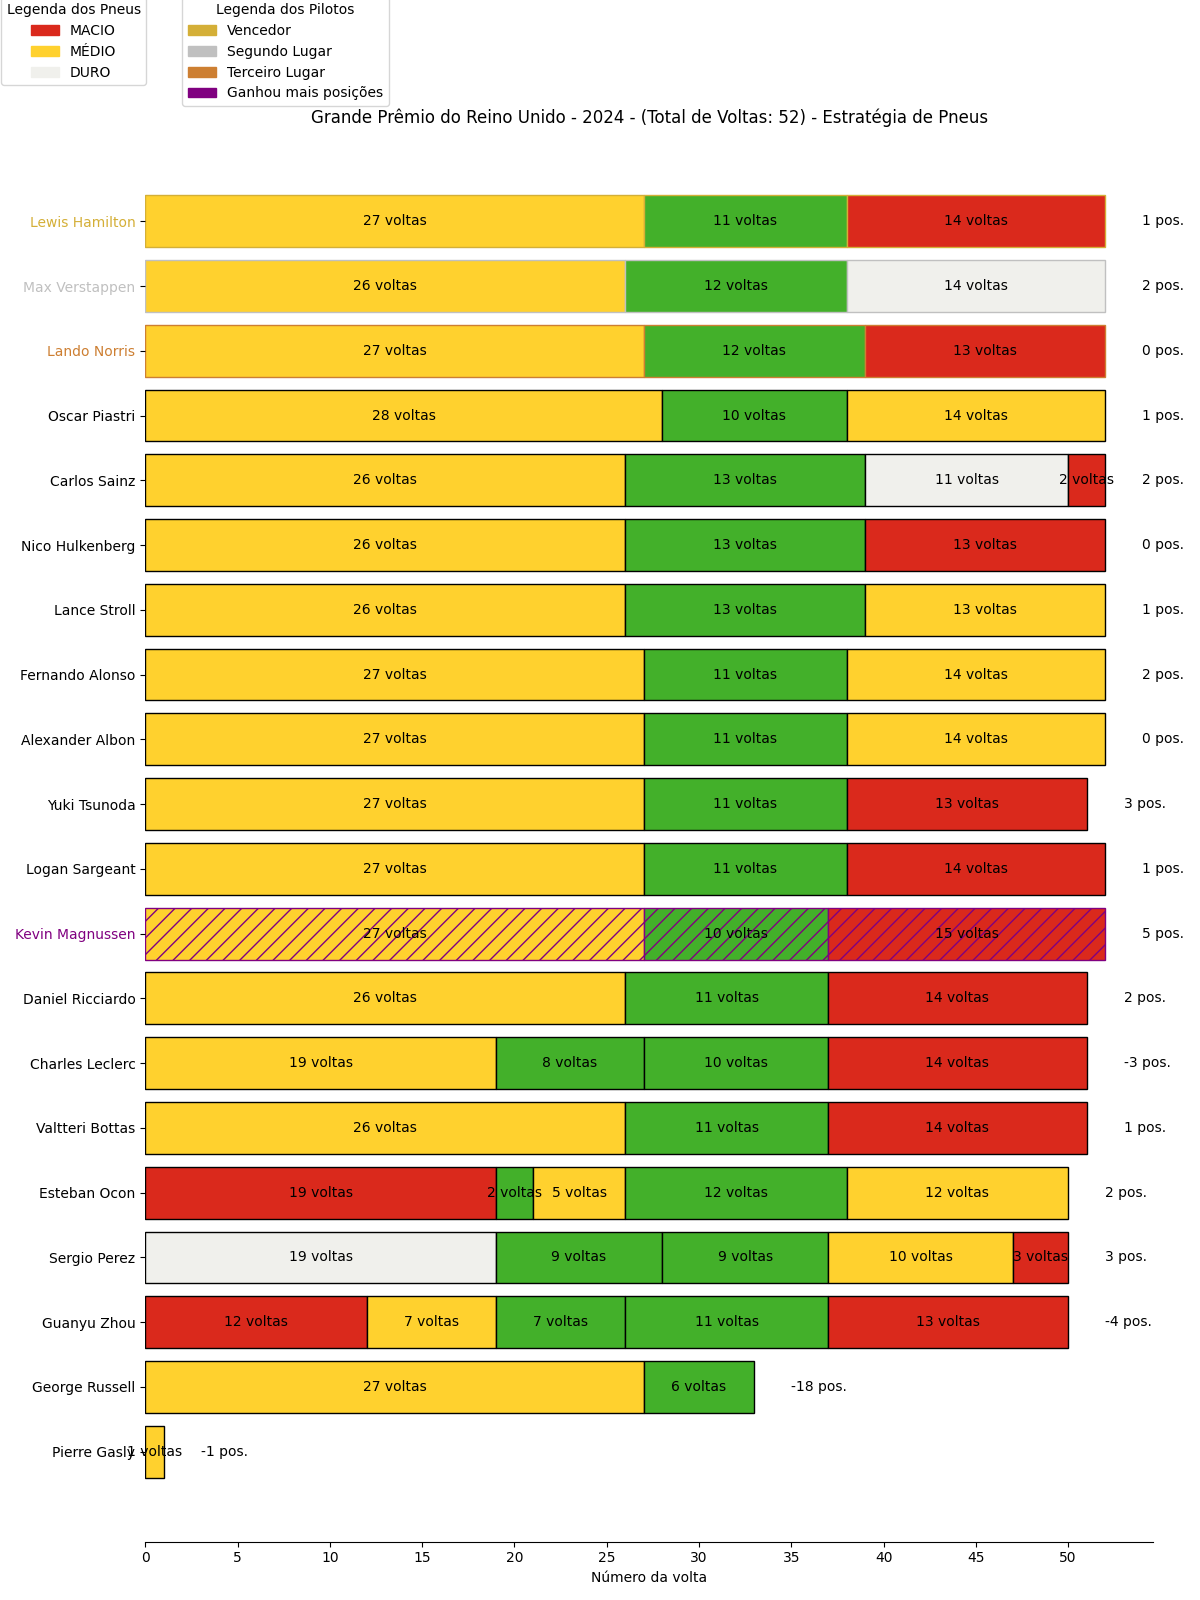

In [51]:
years = [2024]
countries = ['Reino Unido']

for year in years:
    for country in countries:
            get_tyre_strategy_by_year_and_country(df_barras, year, country)

### Gráfico de barras segmentados dos pilotos com os melhores desempenhos para determinado circuito

In [56]:
def plot_best_drivers_strategy(df, country):
    # Anos que vamos analisar
    years = [2019, 2020, 2021, 2022, 2023, 2024]
    
    # Dicionário para armazenar as melhores informações de cada ano
    best_drivers = {}
    fig, ax = plt.subplots(figsize=(16, 9), facecolor='#FFFFFF')
    
    compound_colors = {
        'SOFT': '#da291c',
        'MEDIUM': '#ffd12e',
        'HARD': '#f0f0ec',
        'INTERMEDIATE': '#43b02a',
        'WET': '#0067ad'
    }
    
    bar_positions = []

    country_data = df[(df['Country'] == country)]
    # Setando o total de laps
    total_laps = country_data['LapNumber'].max()
    for year in years:
        # Filtrar dados pelo ano e país
        yearly_data = country_data[(country_data['Year'] == year)]
        
        # Calcular o número de posições ganhas por piloto
        position_changes = yearly_data.groupby('FullName').apply(
            lambda g: g['GridPosition'].iloc[0] - g['FinalPosition'].iloc[-1], include_groups=False)

        # Encontrar o piloto com o máximo de posições ganhas
        max_positions_gained = position_changes.max()
        top_drivers = position_changes[position_changes == max_positions_gained].index.tolist()
        best_drivers[year] = (top_drivers, max_positions_gained)
    
        for driver in best_drivers.get(year, [[], 0])[0]:
            driver_data = df[(df['Year'] == year) & (df['Country'] == country) & (df['FullName'] == driver)]
            
            stints = driver_data[["FullName", "Stint", "Compound", "LapNumber"]]
            stints = stints.groupby(["FullName", "Stint", "Compound"]).count().reset_index()
            stints = stints.rename(columns={"LapNumber": "StintLength"})
            
            previous_stint_end = 0
            for idx, row in stints.iterrows():
                bars = plt.barh(
                    y=f'{driver} ({year})',
                    width=row["StintLength"],
                    left=previous_stint_end,
                    color=compound_colors[row['Compound']],
                    edgecolor='black'
                )

                ax.text(
                    previous_stint_end + row["StintLength"] / 2,
                    f'{driver} ({year})',
                    f'{row["StintLength"]} laps',
                    va='center',
                    ha='center',
                    color='black',
                    fontsize=10
                )

                previous_stint_end += row["StintLength"]

            ax.text(
                previous_stint_end + 1,
                f'{driver} ({year})',
                f'{int(best_drivers[year][1])} pos.',
                va='center',
                color='black',
                fontsize=10
            )
            
            bar_positions.append(f'{driver} ({year})')
    
    # Adicionar a legenda dos pneus
    tyre_legend = [
        mpatches.Patch(color=compound_colors['SOFT'], label='MACIO'),
        mpatches.Patch(color=compound_colors['MEDIUM'], label='MÉDIO'),
        mpatches.Patch(color=compound_colors['HARD'], label='DURO'),
        mpatches.Patch(color=compound_colors['INTERMEDIATE'], label='INTERMEDIÁRIO'),
        mpatches.Patch(color=compound_colors['WET'], label='CHUVA')
    ]
    plt.legend(handles=tyre_legend, title="Compostos de Pneus", loc='upper left', bbox_to_anchor=(-0.15, 1.1))
    
    plt.title(f'Estratégia de pneus para os pilotos mais eficientes - {country} Grand Prix - (2019-2023) ', color='black')
    plt.xlabel('Número da volta', color='#000000')
    plt.ylabel('Piloto (Ano)', color='#000000')
    
    ax.set_facecolor('#FFFFFF')
    ax.set_xticks(range(0, int(total_laps) + 1, 5))
    ax.tick_params(axis='x', colors='#000000')  # Cor dos números no eixo X
    ax.tick_params(axis='y', colors='#000000')  # Cor dos números no eixo Y
    plt.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#000000')
    ax.spines['bottom'].set_linewidth(2)
    
    plt.tight_layout()
    plt.show()

In [53]:
display(df.head(10))

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,PitStops,Composto,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
2,Pierre Gasly,98.794,3.0,1.0,False,True,0.0,MACIO,6.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.3,False
4,Pierre Gasly,98.574,5.0,1.0,False,True,0.0,MACIO,8.0,False,1,11.0,Bahrain,2019,8.0,13.0,Finished,29.2,False
6,Pierre Gasly,100.112,7.0,1.0,False,False,0.0,MACIO,10.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.1,False
7,Pierre Gasly,99.189,8.0,1.0,False,False,0.0,MACIO,11.0,False,1,12.0,Bahrain,2019,8.0,13.0,Finished,29.1,False
8,Pierre Gasly,102.197,9.0,1.0,True,False,0.0,MACIO,12.0,False,1,13.0,Bahrain,2019,8.0,13.0,Finished,28.9,False
9,Pierre Gasly,119.647,10.0,2.0,True,False,1.0,MACIO,1.0,True,1,17.0,Bahrain,2019,8.0,13.0,Finished,28.8,False
10,Pierre Gasly,97.179,11.0,2.0,False,True,1.0,MACIO,2.0,True,1,17.0,Bahrain,2019,8.0,13.0,Finished,28.8,False
12,Pierre Gasly,96.819,13.0,2.0,False,False,1.0,MACIO,4.0,True,1,13.0,Bahrain,2019,8.0,13.0,Finished,28.9,False
13,Pierre Gasly,96.567,14.0,2.0,False,False,1.0,MACIO,5.0,True,1,13.0,Bahrain,2019,8.0,13.0,Finished,28.8,False
14,Pierre Gasly,97.667,15.0,2.0,False,False,1.0,MACIO,6.0,True,1,13.0,Bahrain,2019,8.0,13.0,Finished,28.8,False


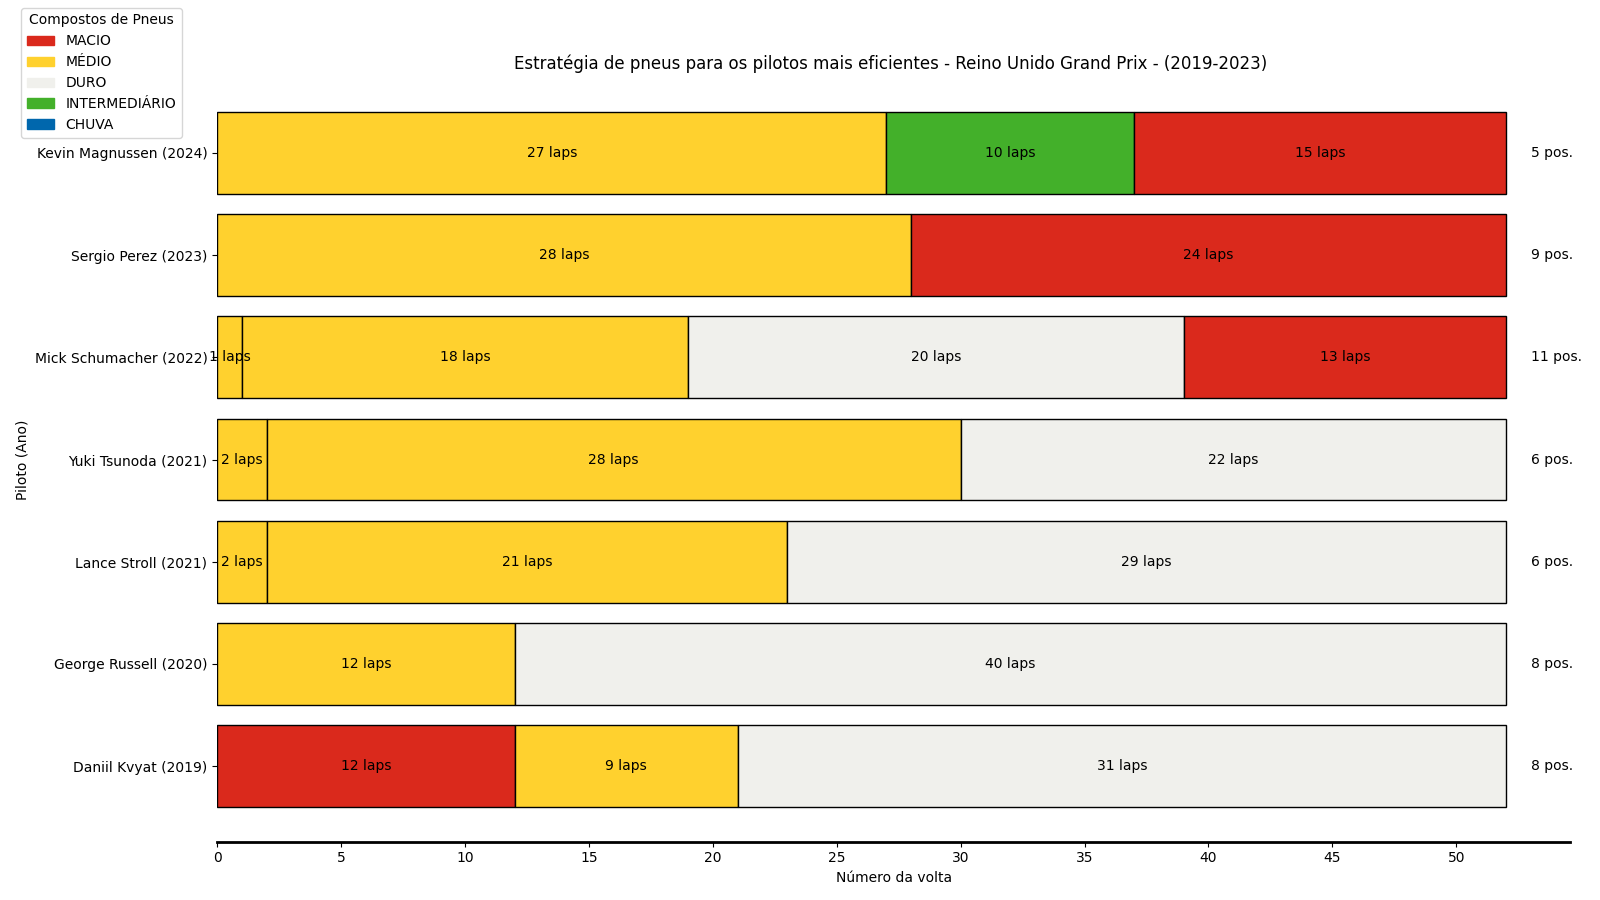

In [57]:
plot_best_drivers_strategy(df_barras, 'Reino Unido')

### Plotando os gráficos de todas as corridas

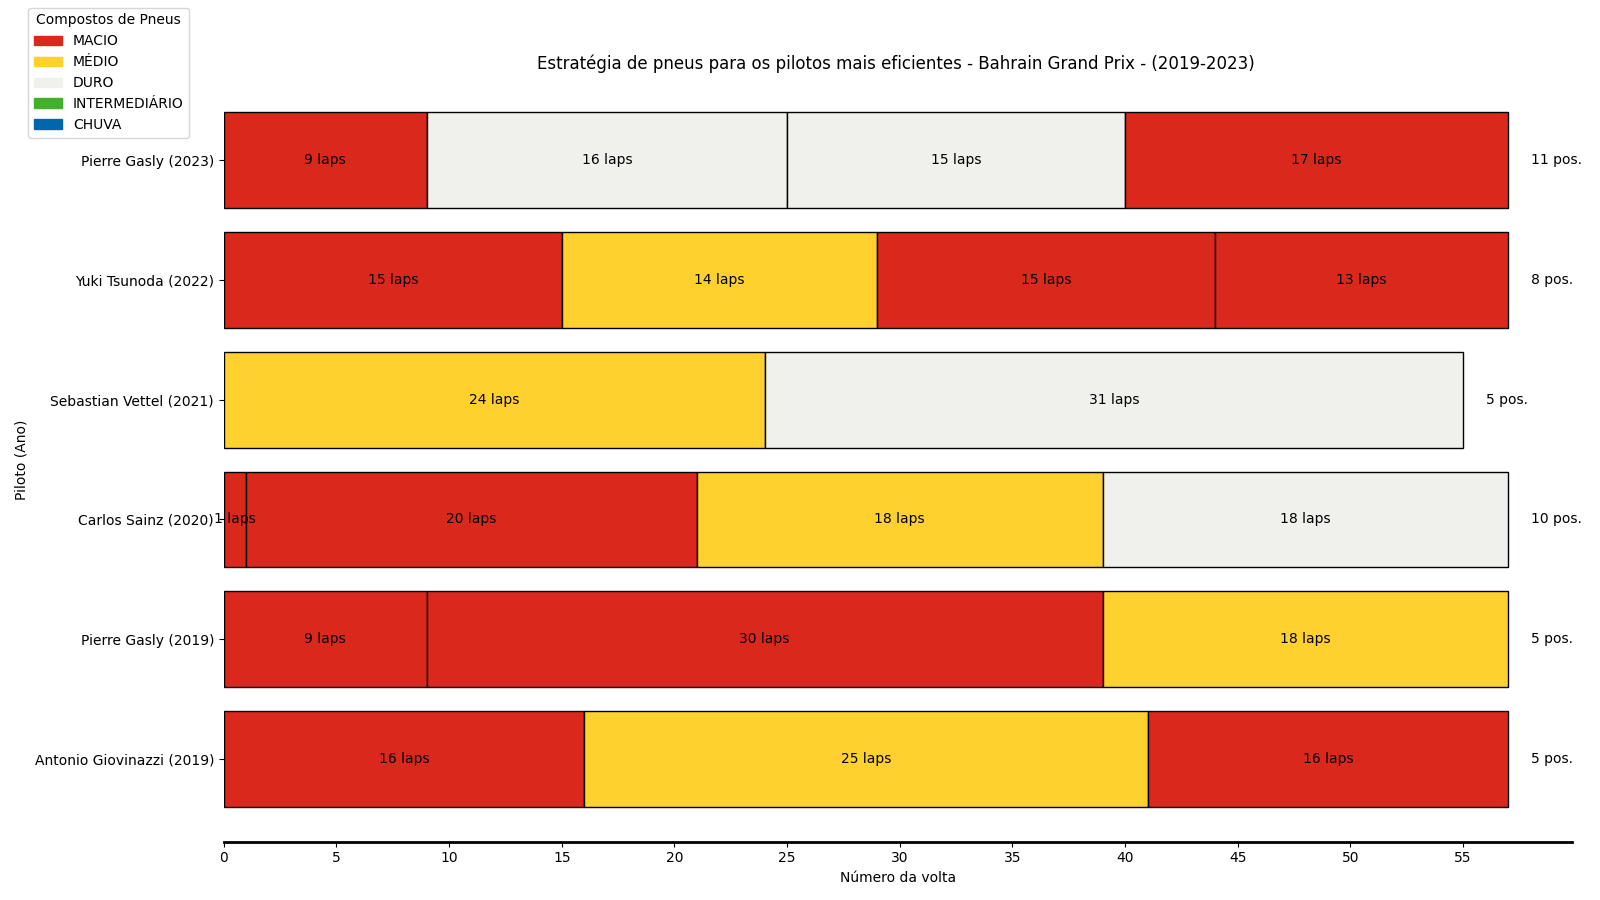

ValueError: cannot convert float NaN to integer

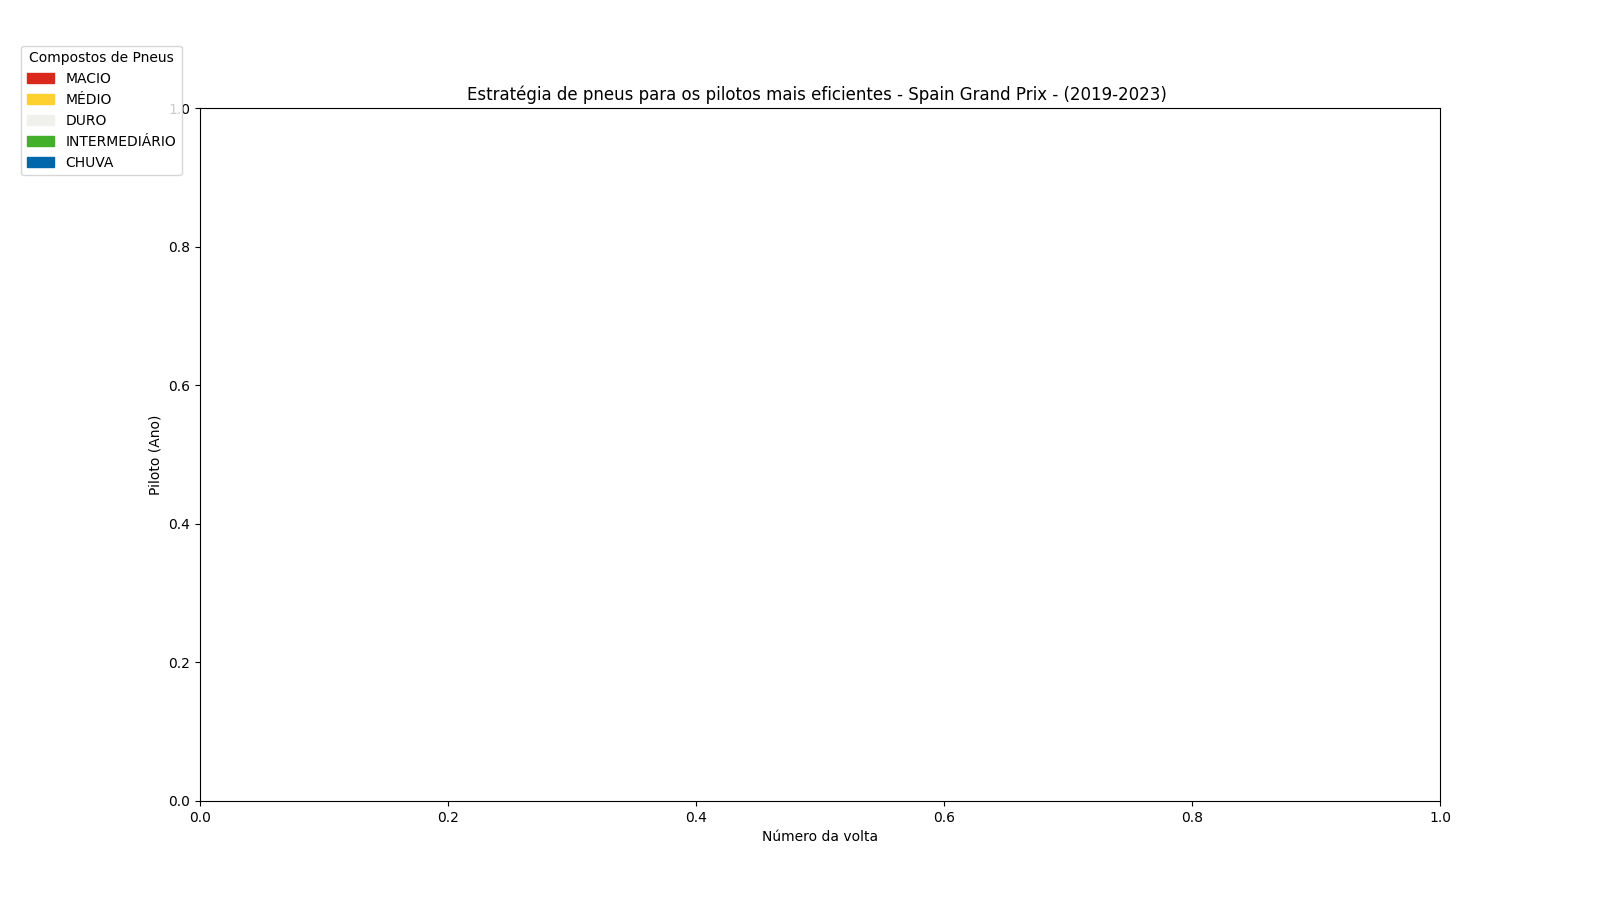

In [58]:
countries = ['Bahrain', 'Spain', 'Austria', 'Great Britain', 'Hungary', 'Italy', 'Abu Dhabi']

for country in countries:
    plot_best_drivers_strategy(df_barras, country)

### Gráfico 3d

In [ ]:
def plot_laptime_tyrecompound_tracktemp(df, year, country):
    compound_colors = {
        'SOFT': '#da291c',
        'MEDIUM': '#ffd12e',
        'HARD': '#000000',
        'INTERMEDIATE': '#43b02a',
        'WET': '#0067ad'
    }

    df = df.loc[(df['Year'] == year) & (df['Country'] == country)]
    df = pd.DataFrame(df).copy()
    # Mapeando tipos de pneus para valores numéricos
    compound_mapping = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3}
    df['CompoundNum'] = df['Compound'].map(compound_mapping)
    df['Color'] = df['Compound'].map(compound_colors)
    # Criando o gráfico 3D
    fig = plt.figure(figsize=(12, 8 ))
    ax = fig.add_subplot(111, projection='3d')

    # Plotando os dados
    ax.scatter(df['LapTime'], df['CompoundNum'], df['TrackTemp'], c=df['Color'], marker='o')

    # Adicionando rótulos
    ax.set_xlabel('Tempo de Volta (LapTime)')
    ax.set_ylabel('Tipo de Pneu (Compound)')
    ax.set_zlabel('Temperatura da Pista (TrackTemp)')

    # Definindo ticks para o eixo Y (Tipos de Pneus)
    ax.set_yticks(list(compound_mapping.values()))
    ax.set_yticklabels(compound_mapping.keys())

    plt.title('Relação entre Tempo de Volta, Tipo de Pneu e Temperatura da Pista')
    plt.show()



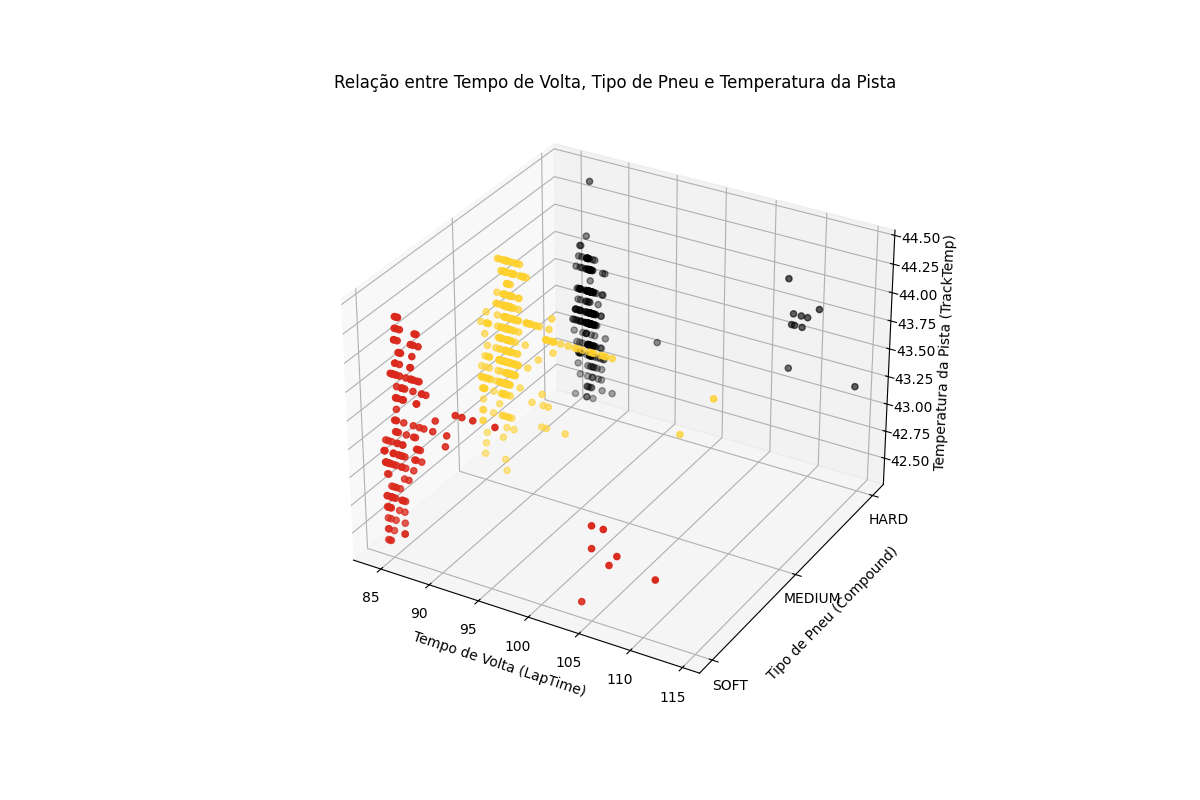

In [ ]:
plot_laptime_tyrecompound_tracktemp(df, 2022, 'Italy')

### Gráfico 3d

In [ ]:
def plot_tyrelife_pitstops_finalposition(df, year, country):
    compound_colors = {
        'SOFT': '#da291c',
        'MEDIUM': '#ffd12e',
        'HARD': '#000000',
        'INTERMEDIATE': '#43b02a',
        'WET': '#0067ad'
    }
    df = df.loc[(df['Year'] == year) & (df['Country'] == country)]
    df = pd.DataFrame(df).copy()

    # Mapear cores para a posição final
    df['Color'] = df['Compound'].map(compound_colors)

    # Criando o gráfico 3D
    fig = plt.figure(figsize=(12, 8 ))
    ax = fig.add_subplot(111, projection='3d')

    # Plotando os dados com cores
    ax.scatter(df['TyreLife'], df['PitStops'], df['FinalPosition'], c=df['Color'], marker='o')

    # Adicionando rótulos
    ax.set_xlabel('Vida do Pneu (TyreLife)')
    ax.set_ylabel('Número de Pit Stops (PitStops)')
    ax.set_zlabel('Posição Final (FinalPosition)')
    ax.set_zticks(range(1, 21))  # Ticks de 1 até 20
    plt.title('Impacto da Vida do Pneu e Número de Pit Stops na Posição Final')
    plt.show()


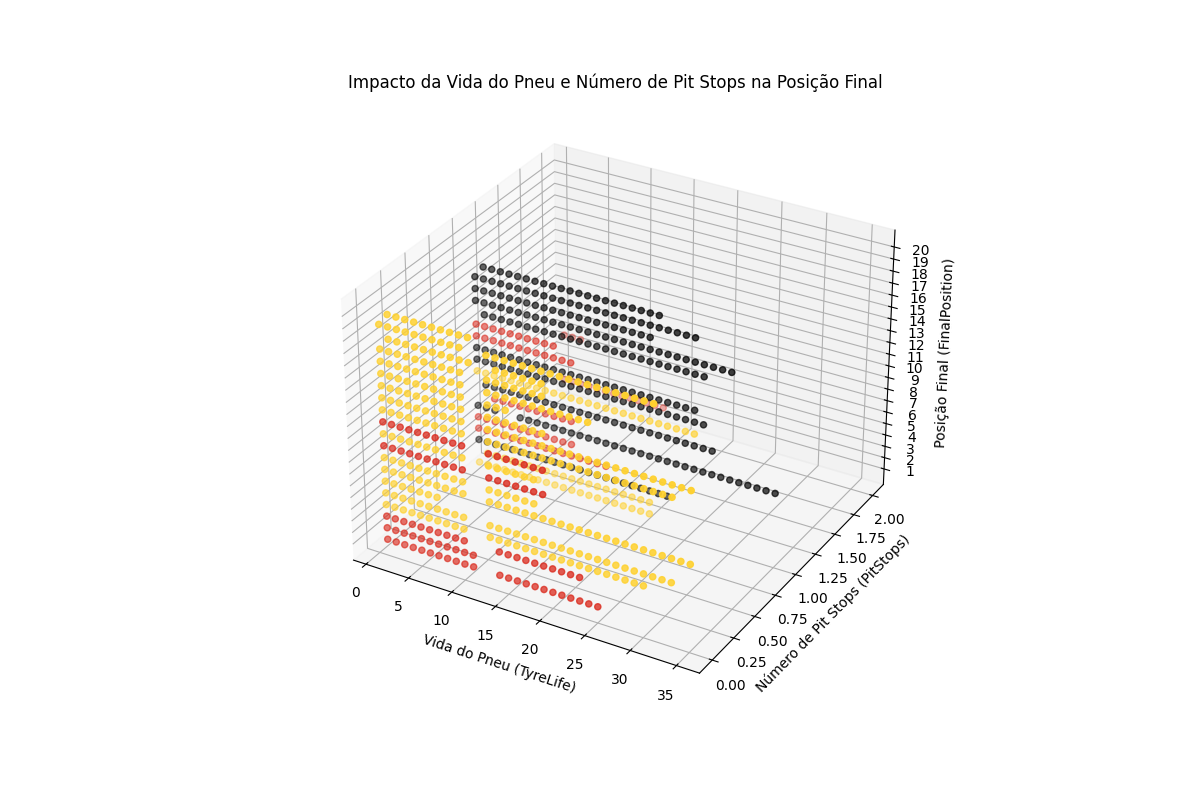

In [ ]:
plot_tyrelife_pitstops_finalposition(df, 2022, 'Italy')

In [59]:
def select_most_efficient_driver(df, year, country):
    df = df.loc[(df['Year'] == year) & (df['Country'] == country)]
    df = pd.DataFrame(df).copy()

    df['GainedPositions'] = df['GridPosition'] - df['FinalPosition']

    piloto_melhor_desempenho = df.loc[df['GainedPositions'].idxmax()]

    pilotos_a_frente = df[df['GridPosition'] < piloto_melhor_desempenho['GridPosition']]
    return piloto_melhor_desempenho
    abandonos_mecanicos = pilotos_a_frente[~pilotos_a_frente['Status'].isin(['Finished', '+1 Lap', '+2 Laps', '+3 Laps', '+5 Laps'])]

    # Filtrar as últimas voltas antes do abandono
    ultima_volta_abandono = abandonos_mecanicos.groupby('FullName')['LapNumber'].max().reset_index()

    # Fazer o merge para obter os dados completos dessas últimas voltas
    dados_abandono_final = pd.merge(ultima_volta_abandono, df, on=['FullName', 'LapNumber'], how='left')

    posicoes_ganhas_reais = piloto_melhor_desempenho['GainedPositions'] - dados_abandono_final.shape[0]

    return posicoes_ganhas_reais

In [60]:
select_most_efficient_driver(df, 2024, 'Reino Unido')

FullName           Kevin Magnussen
LapTime                    103.681
LapNumber                      1.0
Stint                          1.0
PitStopBool                  False
IsPersonalBest               False
PitStops                       0.0
Composto                     MÉDIO
TyreLife                       1.0
FreshTyre                     True
TrackStatus                      1
CurrentPosition               17.0
Country                Reino Unido
Year                          2024
FinalPosition                 12.0
GridPosition                  17.0
Status                    Finished
TrackTemp                     33.0
Rainfall                     False
GainedPositions                5.0
Name: 48602, dtype: object

In [61]:
def plot_best_drivers_strategy_with_true_positions(df, country):
    # Anos que vamos analisar
    years = [2019, 2020, 2021, 2022, 2023, 2024]

    fig, ax = plt.subplots(figsize=(16, 9), facecolor='#15151E')
    
    compound_colors = {
        'SOFT': '#da291c',
        'MEDIUM': '#ffd12e',
        'HARD': '#f0f0ec',
        'INTERMEDIATE': '#43b02a',
        'WET': '#0067ad'
    }
    
    bar_positions = []

    country_data = df[(df['Country'] == country)]
    # Setando o total de laps
    total_laps = country_data['LapNumber'].max()
    for year in years:
        # Filtrar dados pelo ano e país
        yearly_data = country_data[(country_data['Year'] == year)]
        
        yearly_data['GainedPositions'] = yearly_data['GridPosition'] - yearly_data['FinalPosition']

        max_positions = yearly_data['GainedPositions'].max()

        piloto_melhor_desempenho = yearly_data.loc[yearly_data['GainedPositions'] == max_positions] 

        lista_pilotos = piloto_melhor_desempenho['FullName'].unique()

        for driver in lista_pilotos:
            driver_data = df[(df['Year'] == year) & (df['Country'] == country) & (df['FullName'] == driver)]

            driver_data['GainedPositions'] = driver_data['GridPosition'] - driver_data['FinalPosition']

            pilotos_a_frente = yearly_data[yearly_data['GridPosition'] < driver_data['GridPosition'].max()]

            abandonos_mecanicos = pilotos_a_frente[~pilotos_a_frente['Status'].isin(['Finished', '+1 Lap', '+2 Laps', '+3 Laps', '+5 Laps'])]

            # Filtrar as últimas voltas antes do abandono
            ultima_volta_abandono = abandonos_mecanicos.groupby('FullName')['LapNumber'].max().reset_index()

            # Fazer o merge para obter os dados completos dessas últimas voltas
            dados_abandono_final = pd.merge(ultima_volta_abandono, driver_data, on=['FullName', 'LapNumber'], how='left')

            piloto_melhor_desempenho['TrueGainedPositions'] = piloto_melhor_desempenho['GainedPositions'] - dados_abandono_final.shape[0]

            stints = driver_data[["FullName", "Stint", "Compound", "LapNumber"]]
            stints = stints.groupby(["FullName", "Stint", "Compound"]).count().reset_index()
            stints = stints.rename(columns={"LapNumber": "StintLength"})
            
            posicoes_reais = piloto_melhor_desempenho['TrueGainedPositions'].max()

            previous_stint_end = 0
            for idx, row in stints.iterrows():
                bars = plt.barh(
                    y=f'{driver} ({year})',
                    width=row["StintLength"],
                    left=previous_stint_end,
                    color=compound_colors[row['Compound']],
                    edgecolor='white'
                )

                ax.text(
                    previous_stint_end + row["StintLength"] / 2,
                    f'{driver} ({year})',
                    f'{row["StintLength"]} laps',
                    va='center',
                    ha='center',
                    color='black',
                    fontsize=10
                )          

                previous_stint_end += row["StintLength"]

            ax.text(
                previous_stint_end + 1,
                f'{driver} ({year})',
                f'{posicoes_reais} pos.',
                va='center',
                color='white',
                fontsize=10)
            

            
            bar_positions.append(f'{driver} ({year})')
    
    # Adicionar a legenda dos pneus
    tyre_legend = [
        mpatches.Patch(color=compound_colors['SOFT'], label='MACIO'),
        mpatches.Patch(color=compound_colors['MEDIUM'], label='MÉDIO'),
        mpatches.Patch(color=compound_colors['HARD'], label='DURO')
        #mpatches.Patch(color=compound_colors['INTERMEDIATE'], label='INTERMEDIATE'),
        #mpatches.Patch(color=compound_colors['WET'], label='WET')
    ]
    plt.legend(handles=tyre_legend, title="Compostos de Pneus", loc='upper left', bbox_to_anchor=(-0.15, 1.1))
    
    plt.title(f'Pilotos mais eficientes - (2019-2023) - {country}', color='white')
    plt.xlabel('Número da Volta', color='#FF1E00')
    plt.ylabel('Piloto (Ano)', color='#FF1E00')
    
    ax.set_facecolor('#15151E')
    ax.set_xticks(range(0, int(total_laps) + 1, 5))
    ax.tick_params(axis='x', colors='#FF1E00')  # Cor dos números no eixo X
    ax.tick_params(axis='y', colors='#FF1E00')  # Cor dos números no eixo Y
    plt.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#FF1E00')
    ax.spines['bottom'].set_linewidth(2)
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_23948/3826406413.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_data['GainedPositions'] = yearly_data['GridPosition'] - yearly_data['FinalPosition']
/tmp/ipykernel_23948/3826406413.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  driver_data['GainedPositions'] = driver_data['GridPosition'] - driver_data['FinalPosition']
/tmp/ipykernel_23948/3826406413.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

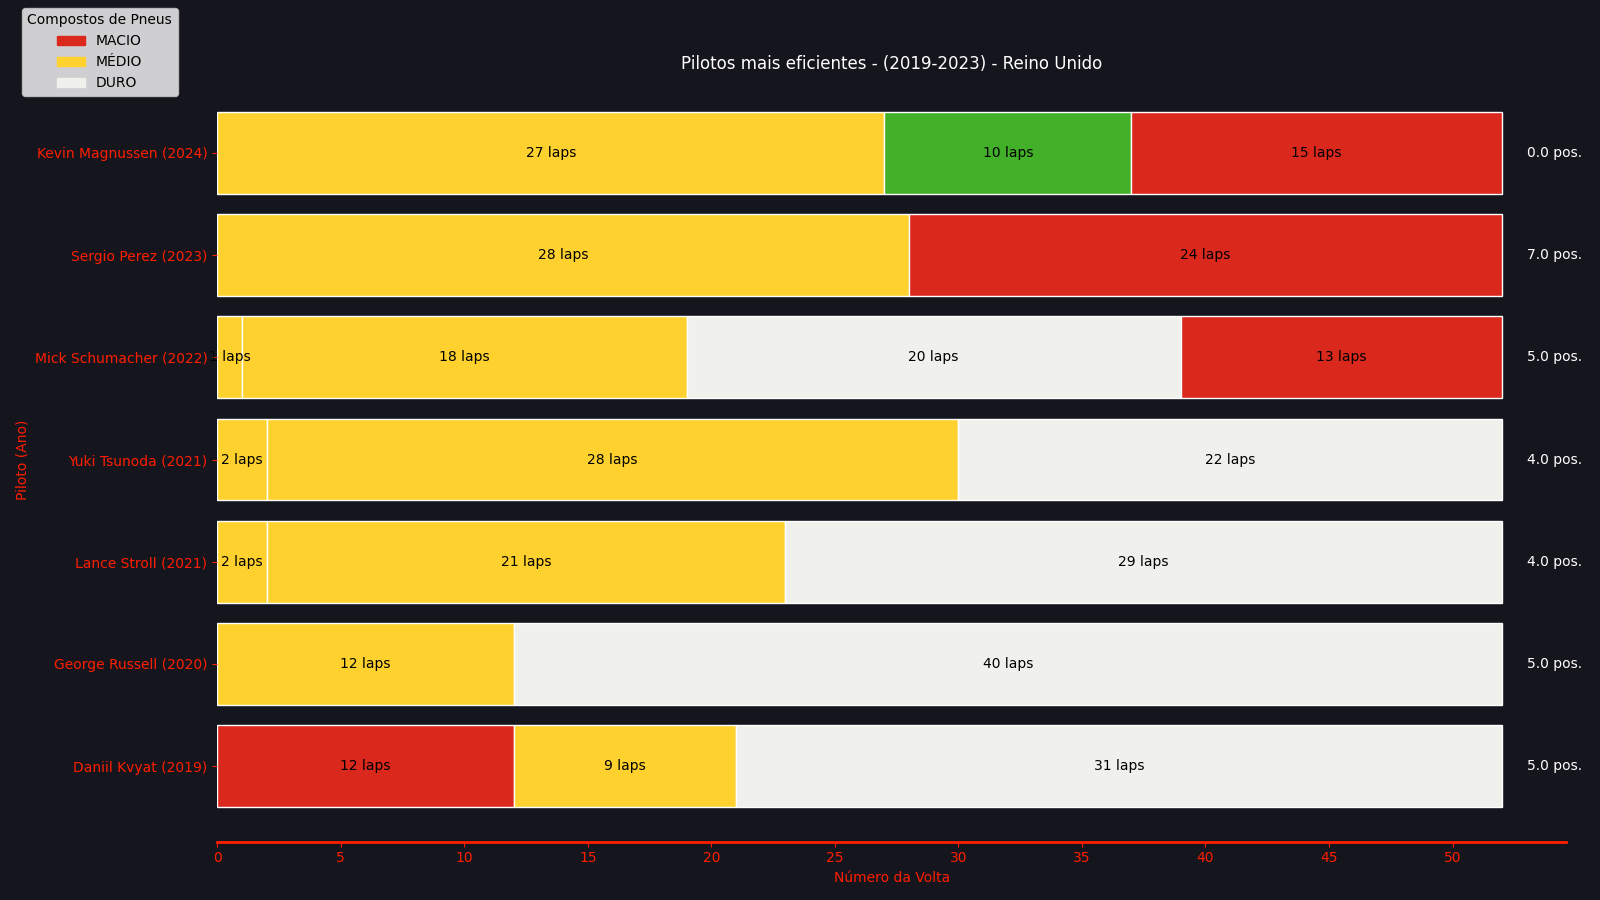

In [62]:
plot_best_drivers_strategy_with_true_positions(df_barras, 'Reino Unido')

In [ ]:
def analise_para_algoritmo_genetico(df, country):
    df = df.loc[(df['Country'] == country) & (df['Year'].isin([2024]))]
    display(df.head(5))
    df = pd.DataFrame(df).copy()

    # Agrupa os dados por 'Compound' e 'TyreLife', e calcula a média dos tempos de volta
    avg_lap_time_per_tyre = df.groupby(['Composto', 'TyreLife']).agg({'LapTime': 'mean'}).reset_index()

    # Cria o dicionário no formato desejado
    lap_time_dict = avg_lap_time_per_tyre.groupby('Composto')['LapTime'].apply(list).to_dict()
    #display(avg_lap_time_per_tyre)
    total_race_time_per_driver = df.groupby(['FullName', 'Year'])['LapTime'].sum().reset_index()
    display(total_race_time_per_driver)
    winner = df.loc[df['FinalPosition'] == 1]   
   # print('total de voltas hard computadas -> ' + str(len(lap_time_dict['HARD'])))
    #print('total de voltas medium computadas -> ' + str(len(lap_time_dict['MEDIUM'])))
    #print('total de voltas soft computadas -> ' + str(len(lap_time_dict['SOFT'])))
    #print(winner)

In [64]:
analise_para_algoritmo_genetico(df, 'Reino Unido')

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,PitStops,Composto,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
41384,Max Verstappen,97.167,1.0,1.0,False,False,0.0,MÉDIO,1.0,True,1,2.0,Reino Unido,2023,1.0,1.0,Finished,29.6,False
41385,Max Verstappen,93.433,2.0,1.0,False,True,0.0,MÉDIO,2.0,True,1,2.0,Reino Unido,2023,1.0,1.0,Finished,29.6,False
41386,Max Verstappen,92.730,3.0,1.0,False,True,0.0,MÉDIO,3.0,True,1,2.0,Reino Unido,2023,1.0,1.0,Finished,29.4,False
41387,Max Verstappen,92.780,4.0,1.0,False,False,0.0,MÉDIO,4.0,True,1,2.0,Reino Unido,2023,1.0,1.0,Finished,29.3,False
41388,Max Verstappen,92.582,5.0,1.0,False,True,0.0,MÉDIO,5.0,True,1,1.0,Reino Unido,2023,1.0,1.0,Finished,29.3,False


,FullName,Year,LapTime
0,Alexander Albon,2023,4196.221
1,Carlos Sainz,2023,4203.090
2,Charles Leclerc,2023,4198.379
3,Esteban Ocon,2023,856.351
4,Fernando Alonso,2023,4190.582
5,George Russell,2023,4192.329
6,Guanyu Zhou,2023,4240.210
7,Kevin Magnussen,2023,2935.905
8,Lance Stroll,2023,4205.931
9,Lando Norris,2023,4252.352


In [ ]:
df_gb = df.loc[(df['Country'] == 'Great Britain') & (df['PitStopBool'] == True)]
df_gb = pd.DataFrame(df_gb).copy()

In [ ]:
display(df_gb.head(100))

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,PitStops,Compound,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall
11,Pierre Gasly,91.409,12.0,1.0,True,False,0.0,MEDIUM,17.0,False,1,5.0,Great Britain,2019,4.0,5.0,Finished,31.6,False
12,Pierre Gasly,111.564,13.0,2.0,True,False,1.0,HARD,13.0,False,1,10.0,Great Britain,2019,4.0,5.0,Finished,32.4,False
69,Sergio Perez,91.442,18.0,1.0,True,False,0.0,MEDIUM,18.0,True,1,8.0,Great Britain,2019,17.0,15.0,+1 Lap,33.9,False
75,Sergio Perez,106.538,24.0,2.0,True,False,1.0,HARD,6.0,True,1,17.0,Great Britain,2019,17.0,15.0,+1 Lap,33.3,False
76,Sergio Perez,123.438,25.0,3.0,True,False,2.0,SOFT,1.0,True,1,17.0,Great Britain,2019,17.0,15.0,+1 Lap,34.2,False
97,Sergio Perez,90.531,46.0,3.0,True,False,2.0,SOFT,22.0,True,1,16.0,Great Britain,2019,17.0,15.0,+1 Lap,27.5,False
98,Sergio Perez,111.063,47.0,4.0,True,False,3.0,SOFT,4.0,False,1,17.0,Great Britain,2019,17.0,15.0,+1 Lap,27.5,False
115,Charles Leclerc,91.242,13.0,1.0,True,False,0.0,SOFT,16.0,False,1,3.0,Great Britain,2019,3.0,3.0,Finished,32.4,False
116,Charles Leclerc,111.982,14.0,2.0,True,False,1.0,MEDIUM,4.0,False,1,4.0,Great Britain,2019,3.0,3.0,Finished,33.1,False
167,Lance Stroll,92.289,13.0,1.0,True,False,0.0,MEDIUM,13.0,True,1,13.0,Great Britain,2019,13.0,18.0,Finished,32.4,False


In [ ]:
df_pitstops = df_gb[df_gb['PitStopBool'] == True]

# Ordenar os dados pelo nome do piloto e número da volta
df_pitstops = df_pitstops.sort_values(by=['FullName', 'LapNumber'])

# Para calcular o tempo de pitstop, obtemos a diferença de tempo entre duas voltas consecutivas
df_pitstops['TimeDiff'] = df_pitstops.groupby('FullName')['LapTime'].diff()
display(df_pitstops.head(10))
# Filtrar apenas as linhas onde há um pitstop (PitStops > 0) e há uma volta anterior (TimeDiff não é NaN)
df_pitstops_valid = df_pitstops[(df_pitstops['PitStops'] > 0) & (df_pitstops['TimeDiff'].notna())  & (df_pitstops['TimeDiff'] > 0)]

# Calcular a média do tempo de pitstop
avg_pitstop_time = df_pitstops_valid['TimeDiff'].mean()

round(avg_pitstop_time)

,FullName,LapTime,LapNumber,Stint,PitStopBool,IsPersonalBest,PitStops,Compound,TyreLife,FreshTyre,TrackStatus,CurrentPosition,Country,Year,FinalPosition,GridPosition,Status,TrackTemp,Rainfall,TimeDiff
163,Alexander Albon,95.837,6.0,1.0,True,False,0.0,MEDIUM,6.0,True,1,13.0,Great Britain,2020,8.0,12.0,Finished,40.9,False,NaN
164,Alexander Albon,114.670,7.0,2.0,True,False,1.0,HARD,1.0,True,1,18.0,Great Britain,2020,8.0,12.0,Finished,41.7,False,18.833
225,Alexander Albon,93.003,13.0,1.0,True,False,0.0,SOFT,18.0,False,1,7.0,Great Britain,2019,12.0,9.0,Finished,32.4,False,-21.667
226,Alexander Albon,112.935,14.0,2.0,True,False,1.0,MEDIUM,1.0,True,1,14.0,Great Britain,2019,12.0,9.0,Finished,33.9,False,19.932
187,Alexander Albon,91.204,30.0,2.0,True,False,1.0,HARD,24.0,True,1,13.0,Great Britain,2020,8.0,12.0,Finished,38.3,False,-21.731
188,Alexander Albon,117.525,31.0,3.0,True,False,2.0,MEDIUM,4.0,False,1,17.0,Great Britain,2020,8.0,12.0,Finished,40.4,False,26.321
645,Antonio Giovinazzi,93.119,23.0,2.0,True,False,1.0,MEDIUM,21.0,True,1,10.0,Great Britain,2021,13.0,15.0,+1 Lap,50.5,False,NaN
646,Antonio Giovinazzi,113.252,24.0,3.0,True,False,2.0,HARD,1.0,True,1,15.0,Great Britain,2021,13.0,15.0,+1 Lap,49.8,False,20.133
709,Carlos Sainz,92.799,20.0,2.0,True,False,1.0,MEDIUM,19.0,True,1,1.0,Great Britain,2022,1.0,1.0,Finished,31.6,False,NaN
710,Carlos Sainz,113.892,21.0,3.0,True,False,2.0,HARD,1.0,True,1,3.0,Great Britain,2022,1.0,1.0,Finished,31.5,False,21.093


20